In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_churn.csv")
df.describe()

,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
count,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000,667.000000
mean,102.841079,436.157421,0.079460,0.283358,8.407796,180.948126,100.937031,30.761769,203.355322,100.476762,17.285262,199.685307,100.113943,8.985907,10.238381,4.527736,2.764948,1.563718,0.142429
std,40.819480,41.783305,0.270659,0.450967,13.994480,55.508628,20.396790,9.436463,49.719268,18.948262,4.226160,49.759931,20.172505,2.239429,2.807850,2.482442,0.758167,1.333357,0.349752
min,1.000000,408.000000,0.000000,0.000000,0.000000,25.900000,30.000000,4.400000,48.100000,37.000000,4.090000,23.200000,42.000000,1.040000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,76.000000,408.000000,0.000000,0.000000,0.000000,146.250000,87.500000,24.860000,171.050000,88.000000,14.540000,167.950000,86.000000,7.560000,8.600000,3.000000,2.320000,1.000000,0.000000
50%,102.000000,415.000000,0.000000,0.000000,0.000000,178.300000,101.000000,30.310000,203.700000,101.000000,17.310000,201.600000,100.000000,9.070000,10.500000,4.000000,2.840000,1.000000,0.000000
75%,128.000000,415.000000,0.000000,1.000000,20.000000,220.700000,115.000000,37.520000,236.450000,113.000000,20.095000,231.500000,113.500000,10.420000,12.050000,6.000000,3.255000,2.000000,0.000000
max,232.000000,510.000000,1.000000,1.000000,51.000000,334.300000,165.000000,56.830000,361.800000,168.000000,30.750000,367.700000,175.000000,16.550000,18.300000,18.000000,4.940000,8.000000,1.000000


In [2]:
cols = ["total_day_minutes", "total_eve_minutes", "total_night_minutes", "customer_service_calls"]

summary = pd.DataFrame({
    "mean": df[cols].mean(),
    "median": df[cols].median(),
    "mode": df[cols].mode().iloc[0],
    "std": df[cols].std()
})
summary

,mean,median,mode,std
total_day_minutes,180.948126,178.3,153.5,55.508628
total_eve_minutes,203.355322,203.7,180.5,49.719268
total_night_minutes,199.685307,201.6,188.2,49.759931
customer_service_calls,1.563718,1.0,1.0,1.333357


Day, evening and night minutes have means close to their medians, so they are roughly symmetric. Customer service calls are right-skewed: most customers call once, but a few call much more often.

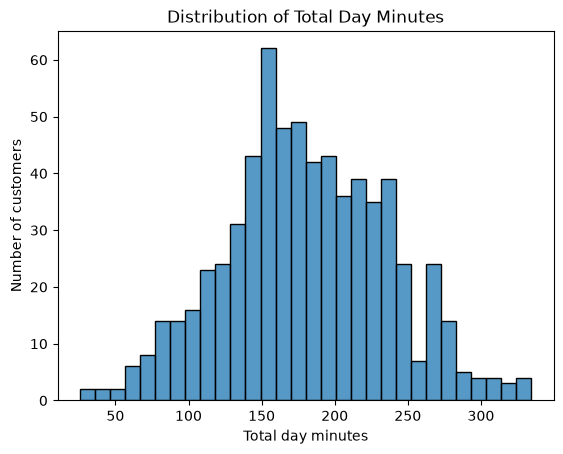

In [3]:
sns.histplot(df["total_day_minutes"], bins=30)
plt.title("Distribution of Total Day Minutes")
plt.xlabel("Total day minutes")
plt.ylabel("Number of customers")
plt.savefig("hist_day_minutes.png", dpi=150, bbox_inches="tight")
plt.show()

Total day minutes are roughly normally distributed, centered near 180 minutes, with few customers at the extremes.

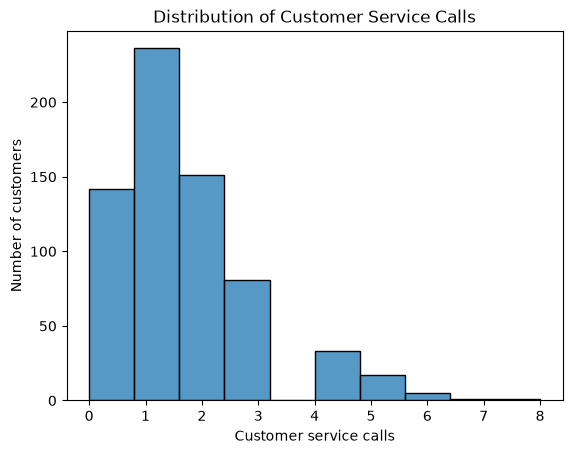

In [4]:
sns.histplot(df["customer_service_calls"], bins=10)
plt.title("Distribution of Customer Service Calls")
plt.xlabel("Customer service calls")
plt.ylabel("Number of customers")
plt.savefig("hist_service_calls.png", dpi=150, bbox_inches="tight")
plt.show()

Most customers contacted customer service once or twice. A small group called 4 or more times, so the distribution is right-skewed.

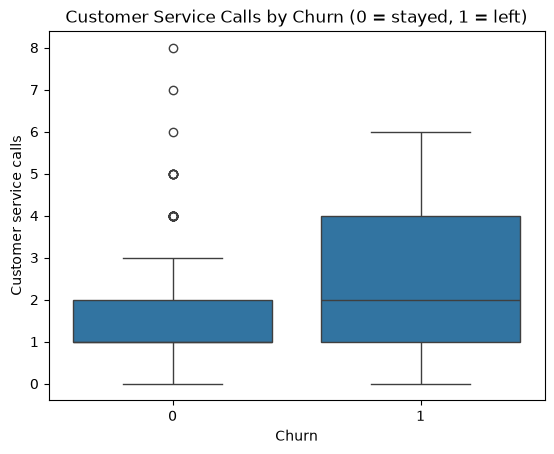

In [5]:
sns.boxplot(x="churn", y="customer_service_calls", data=df)
plt.title("Customer Service Calls by Churn (0 = stayed, 1 = left)")
plt.xlabel("Churn")
plt.ylabel("Customer service calls")
plt.savefig("box_service_calls.png", dpi=150, bbox_inches="tight")
plt.show()

Customers who churned made more customer service calls (median 2) than those who stayed (median 1), and their calls varied more. This suggests frequent support contact may be linked to churn.

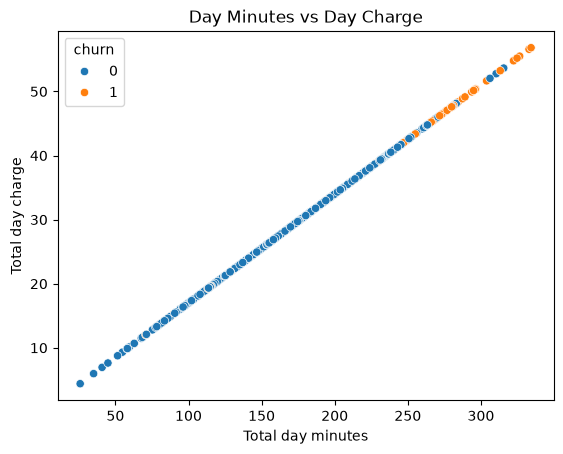

In [6]:
sns.scatterplot(x="total_day_minutes", y="total_day_charge", hue="churn", data=df)
plt.title("Day Minutes vs Day Charge")
plt.xlabel("Total day minutes")
plt.ylabel("Total day charge")
plt.savefig("scatter_day.png", dpi=150, bbox_inches="tight")
plt.show()

Total day charge is perfectly linearly related to total day minutes, since charge is computed from minutes. Churned customers (orange) appear more often at higher usage levels.

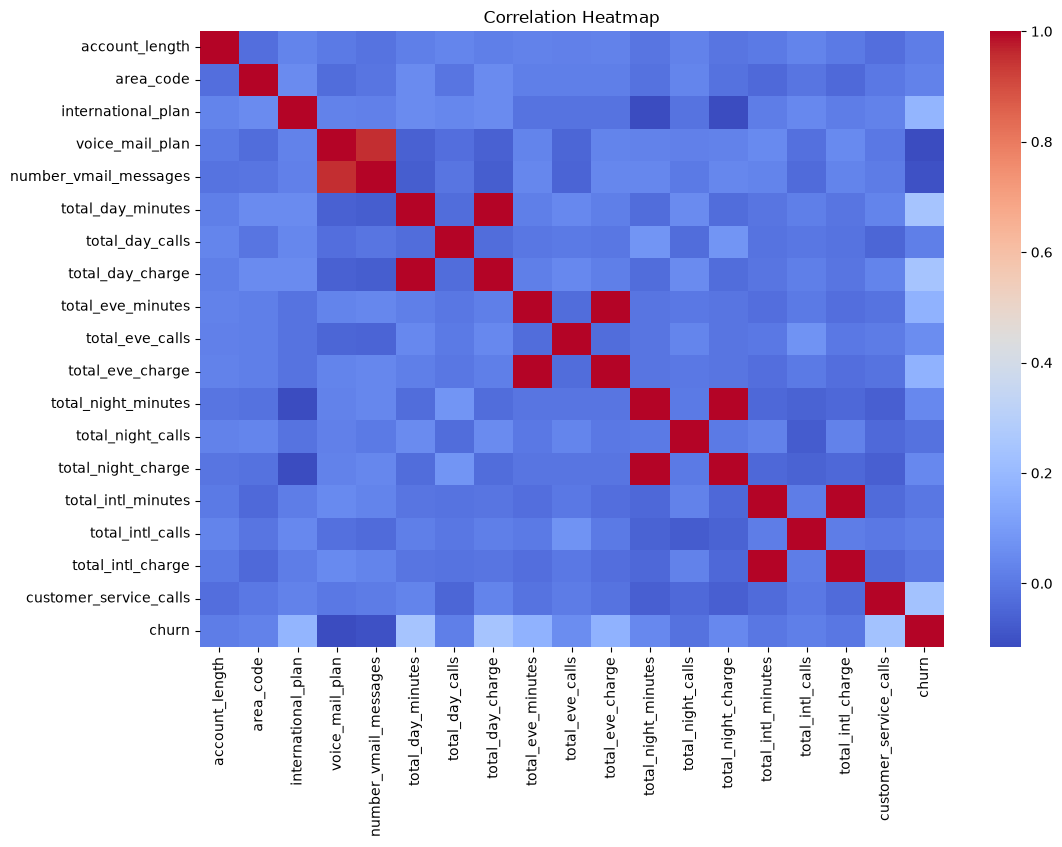

In [7]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.savefig("heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

Minutes and charge columns are almost perfectly correlated for day, evening, night and international usage, because charges are computed from minutes. Voice mail plan and number of voicemail messages are also strongly linked. Most other features show little correlation with each other.

In [8]:
df.corr(numeric_only=True)["churn"].sort_values(ascending=False)

churn                     1.000000
total_day_minutes         0.242781
total_day_charge          0.242777
customer_service_calls    0.233259
international_plan        0.181634
total_eve_charge          0.175616
total_eve_minutes         0.175614
total_eve_calls           0.055669
total_night_charge        0.042958
total_night_minutes       0.042930
area_code                 0.027129
total_day_calls           0.019360
total_intl_calls          0.015331
account_length            0.012315
total_intl_charge        -0.003681
total_intl_minutes       -0.003740
total_night_calls        -0.017626
number_vmail_messages    -0.102381
voice_mail_plan          -0.113465
Name: churn, dtype: float64

Key findings: Churn is most associated with higher day usage (r ≈ 0.24), more customer service calls (r ≈ 0.23) and having an international plan (r ≈ 0.18). Having a voice mail plan is slightly associated with lower churn (r ≈ -0.11). No single feature has a strong correlation with churn, so a multi-feature model is more appropriate for prediction. Minutes and charge columns are redundant and could be reduced in later modelling.